In [1]:
# importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
import sqlite3


In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:
#1 importing database / data

In [5]:

conn = sqlite3.connect('customer_churn.db')

sql_query = """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f'SELECT * FROM {table_name}',conn)
    globals()[f'df_{table_name}'] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [6]:
# print table names and column names
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [7]:
#2. Data cleaning

In [8]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [10]:
df_db_customer.shape

(21, 8)

In [11]:
df_db_customer.rename(columns = {'name':'customer_name'},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [12]:
df_db_customer.drop(columns=['interests','pincode'],inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [13]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [15]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [16]:
df_db_customer['country'].unique()

array(['India', None, 'Nepal'], dtype=object)

In [17]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [18]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [19]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [20]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [21]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [22]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [25]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [26]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [27]:
#3. Feature Engineering and Data Analysis

In [28]:
# create a new column using existing column - churn flag
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [29]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [30]:
df=(df_db_subscription
    .merge(df_db_customer,on = 'customerid',how='left')
    .merge(df_db_support,on = 'customerid',how='left')
)

In [31]:
df.shape

(23, 20)

In [32]:
df_db_subscription['customerid'].nunique()

21

In [33]:
df_db_customer['customerid'].nunique()

21

In [34]:
df_db_support['customerid'].nunique()

7

In [35]:
df_db_support['customerid'].size

9

In [36]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [37]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [38]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [39]:
# merge dataframe
df=(df_db_subscription
    .merge(df_db_customer,on = 'customerid',how='left')
    .merge(df_db_support,on = 'customerid',how='left')
)

In [40]:
df.shape

(21, 21)

In [41]:
df.to_csv('exported_churn_data.csv',index=False)

In [42]:
# Data Analysis

In [43]:
# Churn Rate
churn_rate=df['churn_flag'].mean()*100
print("Churn Rate =", round(churn_rate,2), "%")

Churn Rate = 28.57 %


In [44]:
# Retention Rate
retention_rate=100-churn_rate
print("Retention Rate =", round(retention_rate,2), "%")

Retention Rate = 71.43 %


In [45]:
df.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [46]:
# churn by plan type
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [47]:
# monthly revenue by plan type
monthly_revenue_by_plan=(df.groupby('plan_type')['monthly_charges'].sum().reset_index())
print(monthly_revenue_by_plan)

  plan_type  monthly_charges
0     Basic            52.95
1   Premium           218.93
2  Standard           123.91


In [48]:
# churn by state and sum(revenue) and count of user
churn_by_state=(df.groupby('state').agg(
    churn_rate_pct=('churn_flag',lambda x:round(x.mean()*100,2)),
    total_revenue=('monthly_charges','sum'),
    user_count=("customerid",'count')
).reset_index())
print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [49]:
# churn by subscription type and sum(revenue) and count of users
churn_by_subscription=(df.groupby('subscription_type').agg(
    churn_rate_pct=('churn_flag',lambda x:round(x.mean()*100,2)),
    total_revenue=('monthly_charges','sum'),
    user_count=("customerid",'count')
).reset_index())
print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [50]:
# Average Revenue per User
arpu = df['monthly_charges'].mean()
print('Average Revenue per User :',round(arpu,2))

Average Revenue per User : 18.85


In [51]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [52]:
# Average Customer tenure
# count of days users has used our service: cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure Days = ",round(avg_tenure,0))

Avg Tenure Days =  1497.0


In [53]:
# Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print('Revenue at risk = ',revenue_at_risk)

Revenue at risk =  73.94


In [54]:
# Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print('Escalation Rate =',round(escalation_rate,2),'%')

Escalation Rate = 19.05 %


In [55]:
# Average Complaint per user
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print('Average Complaints per user = ', round(avg_complaints,2))

Average Complaints per user =  0.43


In [56]:
df['escalations']=np.where(df['escalations']=='Y',1,0)

In [57]:
# correlation Esclation vs churn
corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print('Correlation between escalation vs churn is =',round(correlation,2))


Correlation between escalation vs churn is = 0.77


In [58]:
# create a column using existing column - churn risk
conditions = [
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>= 70)
]
choices = ['low','med','high']
df['churn_risk'] = np.select(conditions,choices,default='unknown')

In [59]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1950.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1335.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2625.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,India,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,1490.0,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,India,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,India,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,2345.0,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,Nepal,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,1091.0,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,Nepal,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,1566.0,low


In [60]:
#4. Visualization using matplotlib

In [61]:
df_visual = df.copy()

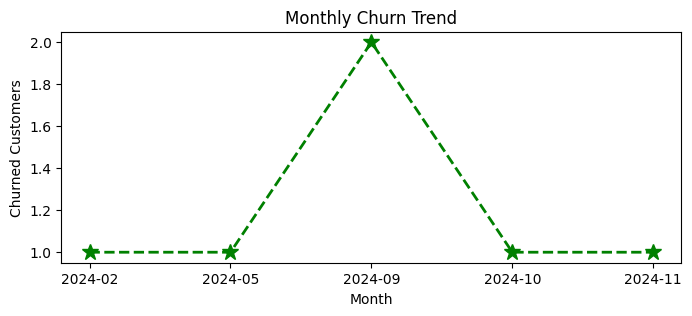

In [62]:
# 4.1 Monthly churn trend(Time series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='*',linestyle='dashed',linewidth=2,markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

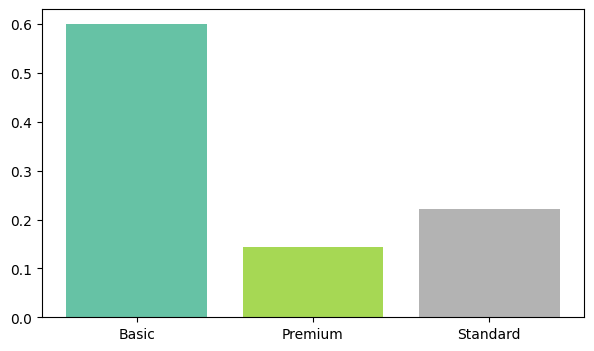

In [63]:
# churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

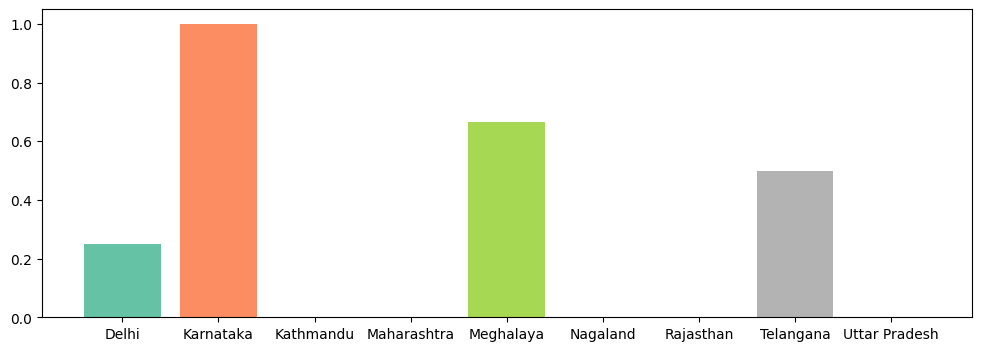

In [64]:
# churn by states
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

In [65]:
#5 Visualization using seaborn

In [66]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [67]:
df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
order_mappings = {
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
}
for col,order in order_mappings.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
                                  

/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_4629/1374111485.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_4629/1374111485.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipy

In [68]:
df_encoded.head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

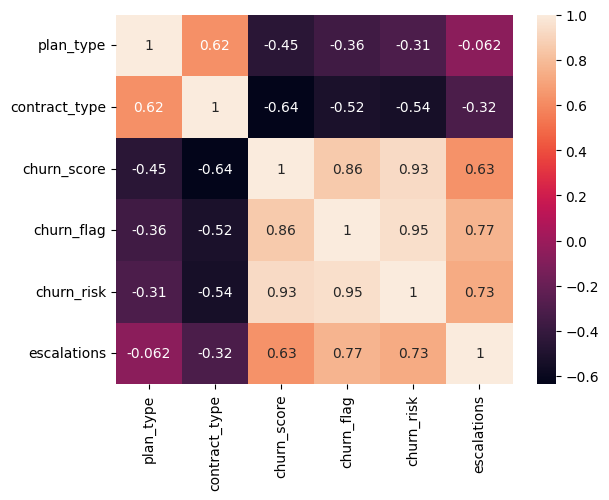

In [69]:
sns.heatmap(df_encoded.corr(),annot=True)

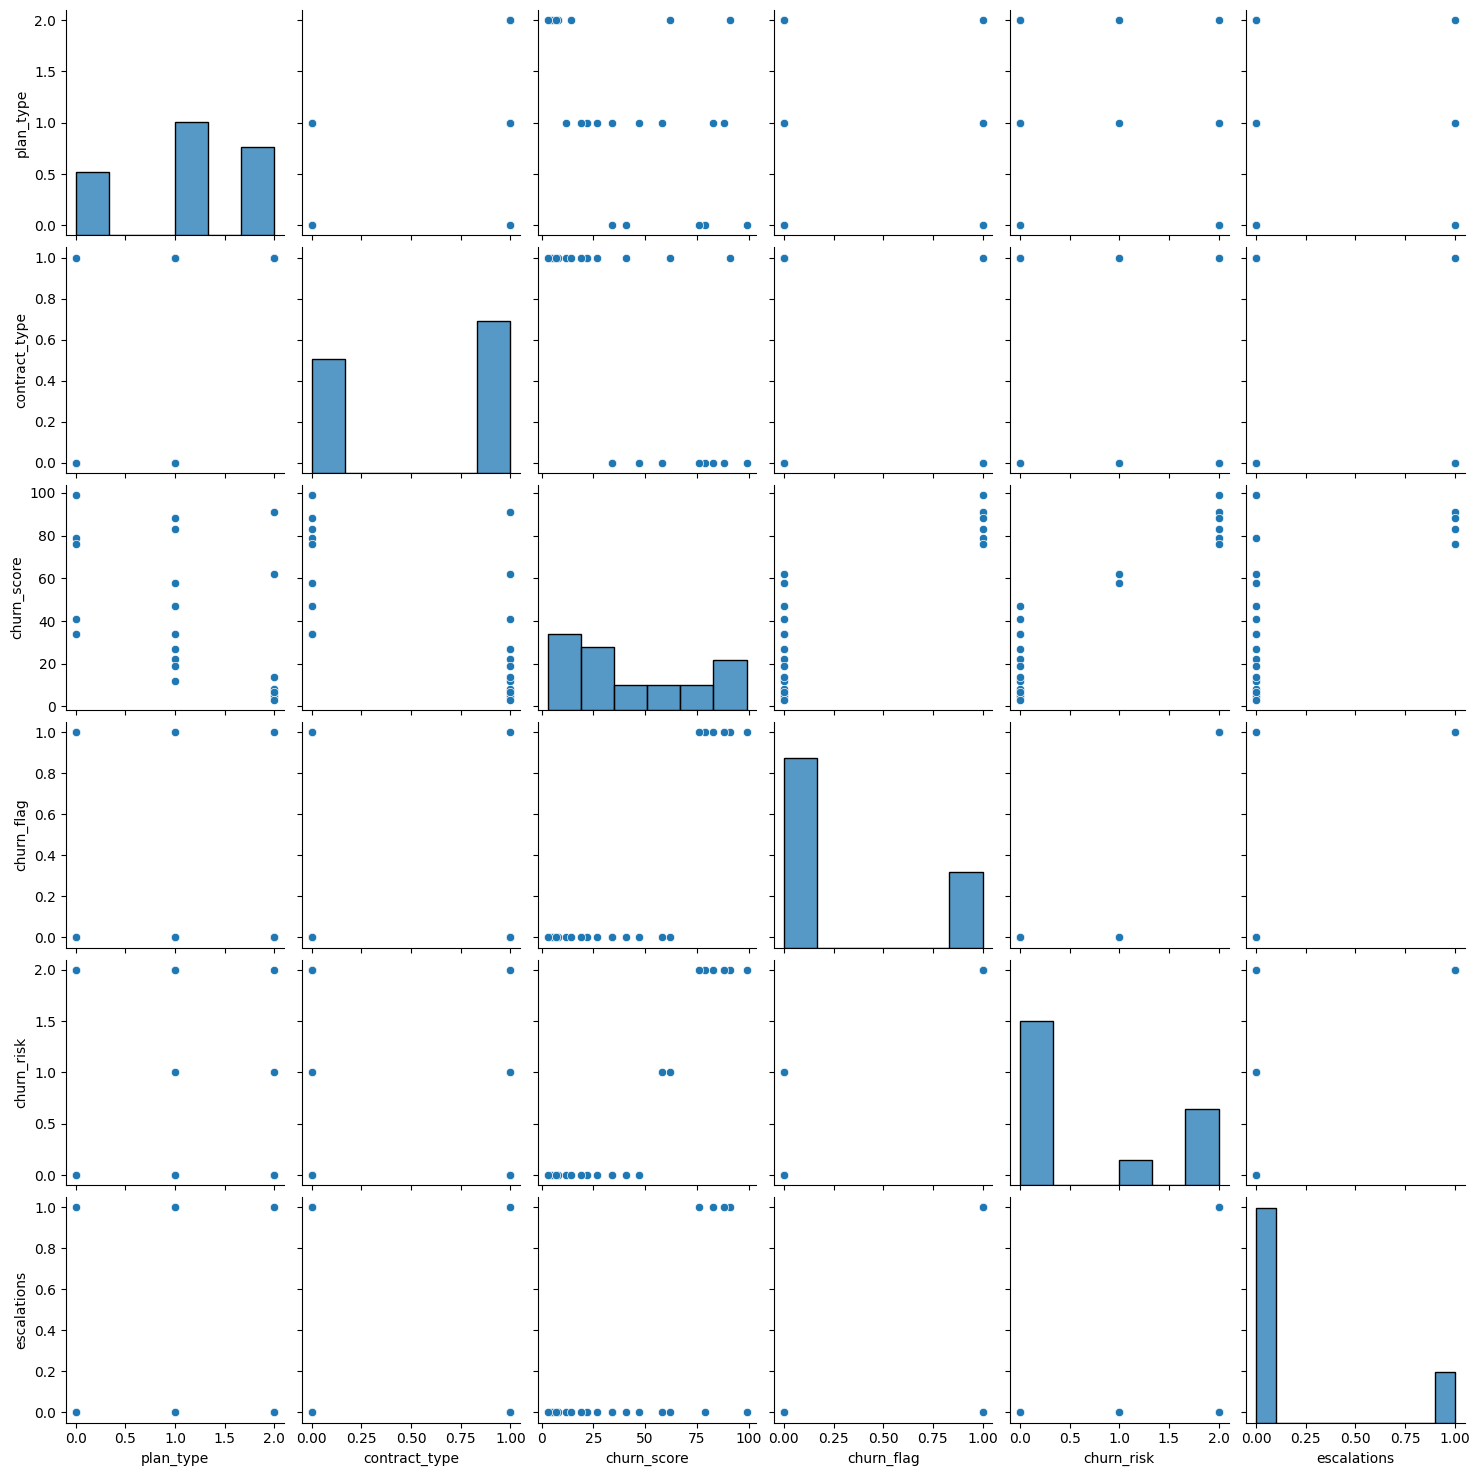

In [70]:
# pairplot
sns.pairplot(df_encoded)

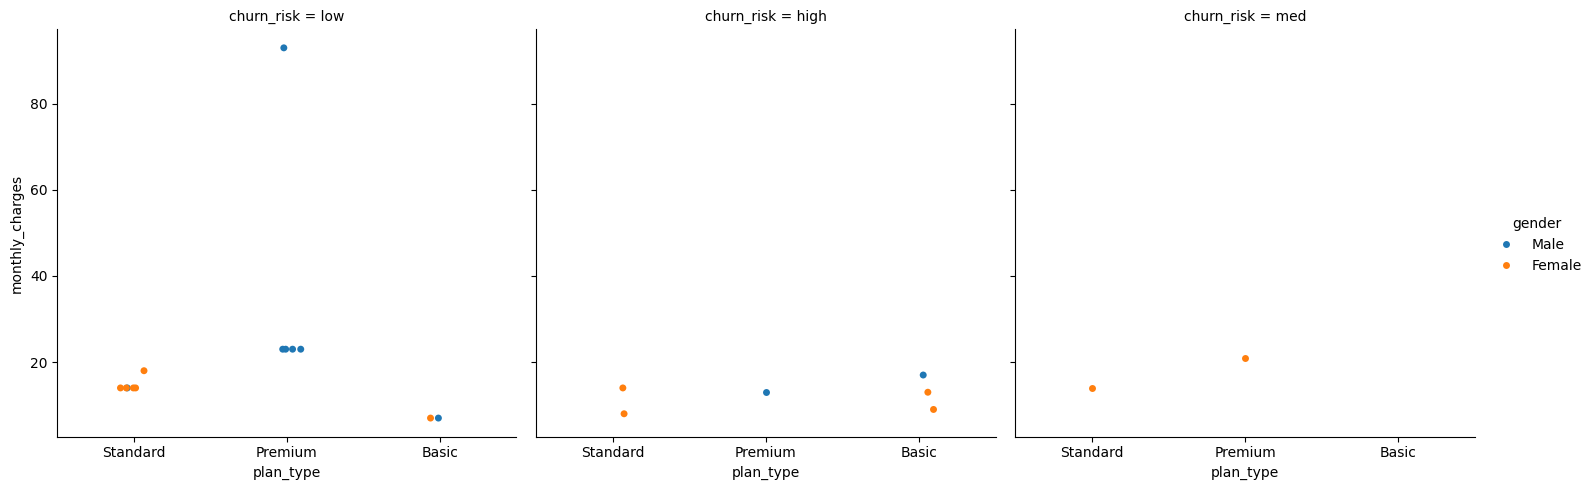

In [71]:
sns.catplot(   data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk',
)